# 🏏 IPL Match Winner Prediction
### End-to-End Machine Learning Project using Random Forest Classifier

---
**Project Overview:**
- Predict IPL match winners based on match conditions
- Uses Random Forest Classifier
- Includes Flask Web App with professional UI
- Complete end-to-end pipeline in a single notebook
---

## 📦 Step 1: Install & Import Libraries

In [1]:
# Install required libraries (uncomment if needed)
# !pip install pandas numpy scikit-learn flask matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 🏏 Step 2: Create Synthetic IPL Dataset
*(Since Kaggle requires authentication, we generate a realistic IPL dataset)*

In [2]:
np.random.seed(42)

# ── IPL Teams & Venues ──────────────────────────────────────────────────────
teams = [
    'Mumbai Indians', 'Chennai Super Kings', 'Royal Challengers Bangalore',
    'Kolkata Knight Riders', 'Delhi Capitals', 'Rajasthan Royals',
    'Sunrisers Hyderabad', 'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants'
]

cities = [
    'Mumbai', 'Chennai', 'Bangalore', 'Kolkata', 'Delhi',
    'Jaipur', 'Hyderabad', 'Chandigarh', 'Ahmedabad', 'Lucknow',
    'Pune', 'Durban', 'Johannesburg', 'Cape Town'
]

toss_decisions = ['bat', 'field']

# ── Generate Matches ─────────────────────────────────────────────────────────
n_matches = 2000
data = []

for _ in range(n_matches):
    batting_team  = np.random.choice(teams)
    bowling_team  = np.random.choice([t for t in teams if t != batting_team])
    city          = np.random.choice(cities)
    toss_winner   = np.random.choice([batting_team, bowling_team])
    toss_decision = np.random.choice(toss_decisions)
    target        = np.random.randint(140, 225)
    overs         = round(np.random.uniform(10.0, 19.5), 1)
    wickets       = np.random.randint(0, 10)

    # Realistic current-score calculation
    balls_left  = max(1, int((20 - overs) * 6))
    wkts_left   = 10 - wickets
    crr_raw     = (target - 20) / max(overs, 1)
    score       = int(crr_raw * overs + np.random.randint(-15, 15))
    score       = max(0, min(score, target - 1))

    # ── Determine winner (probabilistic but logical) ──────────────────────
    runs_needed  = target - score
    rrr          = (runs_needed * 6) / max(balls_left, 1)
    chase_prob   = 1 / (1 + np.exp(0.4 * (rrr - 9)))

    # Toss advantage bump
    if toss_winner == batting_team and toss_decision == 'bat':
        chase_prob -= 0.05
    elif toss_winner == bowling_team and toss_decision == 'field':
        chase_prob += 0.05

    chase_prob = np.clip(chase_prob, 0.05, 0.95)
    result     = batting_team if np.random.random() < chase_prob else bowling_team

    data.append({
        'batting_team' : batting_team,
        'bowling_team' : bowling_team,
        'city'         : city,
        'target'       : target,
        'score'        : score,
        'overs'        : overs,
        'wickets'      : wickets,
        'toss_winner'  : toss_winner,
        'toss_decision': toss_decision,
        'result'       : result
    })

df = pd.DataFrame(data)

print(f'✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

✅ Dataset created: 2000 rows × 10 columns


,batting_team,bowling_team,city,target,score,overs,wickets,toss_winner,toss_decision,result
0,Sunrisers Hyderabad,Kolkata Knight Riders,Johannesburg,211,201,15.7,6,Sunrisers Hyderabad,bat,Sunrisers Hyderabad
1,Punjab Kings,Delhi Capitals,Kolkata,142,130,10.2,1,Delhi Capitals,field,Punjab Kings
2,Rajasthan Royals,Chennai Super Kings,Durban,215,196,15.8,8,Rajasthan Royals,bat,Rajasthan Royals
3,Lucknow Super Giants,Royal Challengers Bangalore,Durban,203,186,14.4,4,Lucknow Super Giants,field,Lucknow Super Giants
4,Gujarat Titans,Sunrisers Hyderabad,Chennai,199,172,15.4,9,Sunrisers Hyderabad,bat,Gujarat Titans
5,Chennai Super Kings,Delhi Capitals,Durban,210,189,15.8,7,Chennai Super Kings,field,Chennai Super Kings
6,Mumbai Indians,Delhi Capitals,Chennai,141,115,14.0,5,Delhi Capitals,field,Mumbai Indians
7,Chennai Super Kings,Royal Challengers Bangalore,Lucknow,153,131,16.9,7,Royal Challengers Bangalore,field,Chennai Super Kings
8,Gujarat Titans,Punjab Kings,Delhi,221,211,15.1,7,Punjab Kings,bat,Punjab Kings
9,Gujarat Titans,Mumbai Indians,Ahmedabad,140,115,11.9,7,Gujarat Titans,bat,Gujarat Titans


## 📊 Step 3: Exploratory Data Analysis (EDA)

In [3]:
print('='*55)
print('           DATASET OVERVIEW')
print('='*55)
print(f'Shape     : {df.shape}')
print(f'Columns   : {list(df.columns)}')
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nData Types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe()

           DATASET OVERVIEW
Shape     : (2000, 10)
Columns   : ['batting_team', 'bowling_team', 'city', 'target', 'score', 'overs', 'wickets', 'toss_winner', 'toss_decision', 'result']

Missing Values:
batting_team     0
bowling_team     0
city             0
target           0
score            0
overs            0
wickets          0
toss_winner      0
toss_decision    0
result           0
dtype: int64

Data Types:
batting_team      object
bowling_team      object
city              object
target             int64
score              int64
overs            float64
wickets            int64
toss_winner       object
toss_decision     object
result            object
dtype: object

Basic Statistics:


,target,score,overs,wickets
count,2000.000000,2000.000000,2000.00000,2000.000000
mean,181.417000,161.127000,14.69305,4.591500
std,24.246506,25.567278,2.73728,2.871193
min,140.000000,106.000000,10.00000,0.000000
25%,160.000000,141.000000,12.20000,2.000000
50%,182.000000,161.000000,14.70000,5.000000
75%,202.250000,182.250000,17.10000,7.000000
max,224.000000,217.000000,19.50000,9.000000


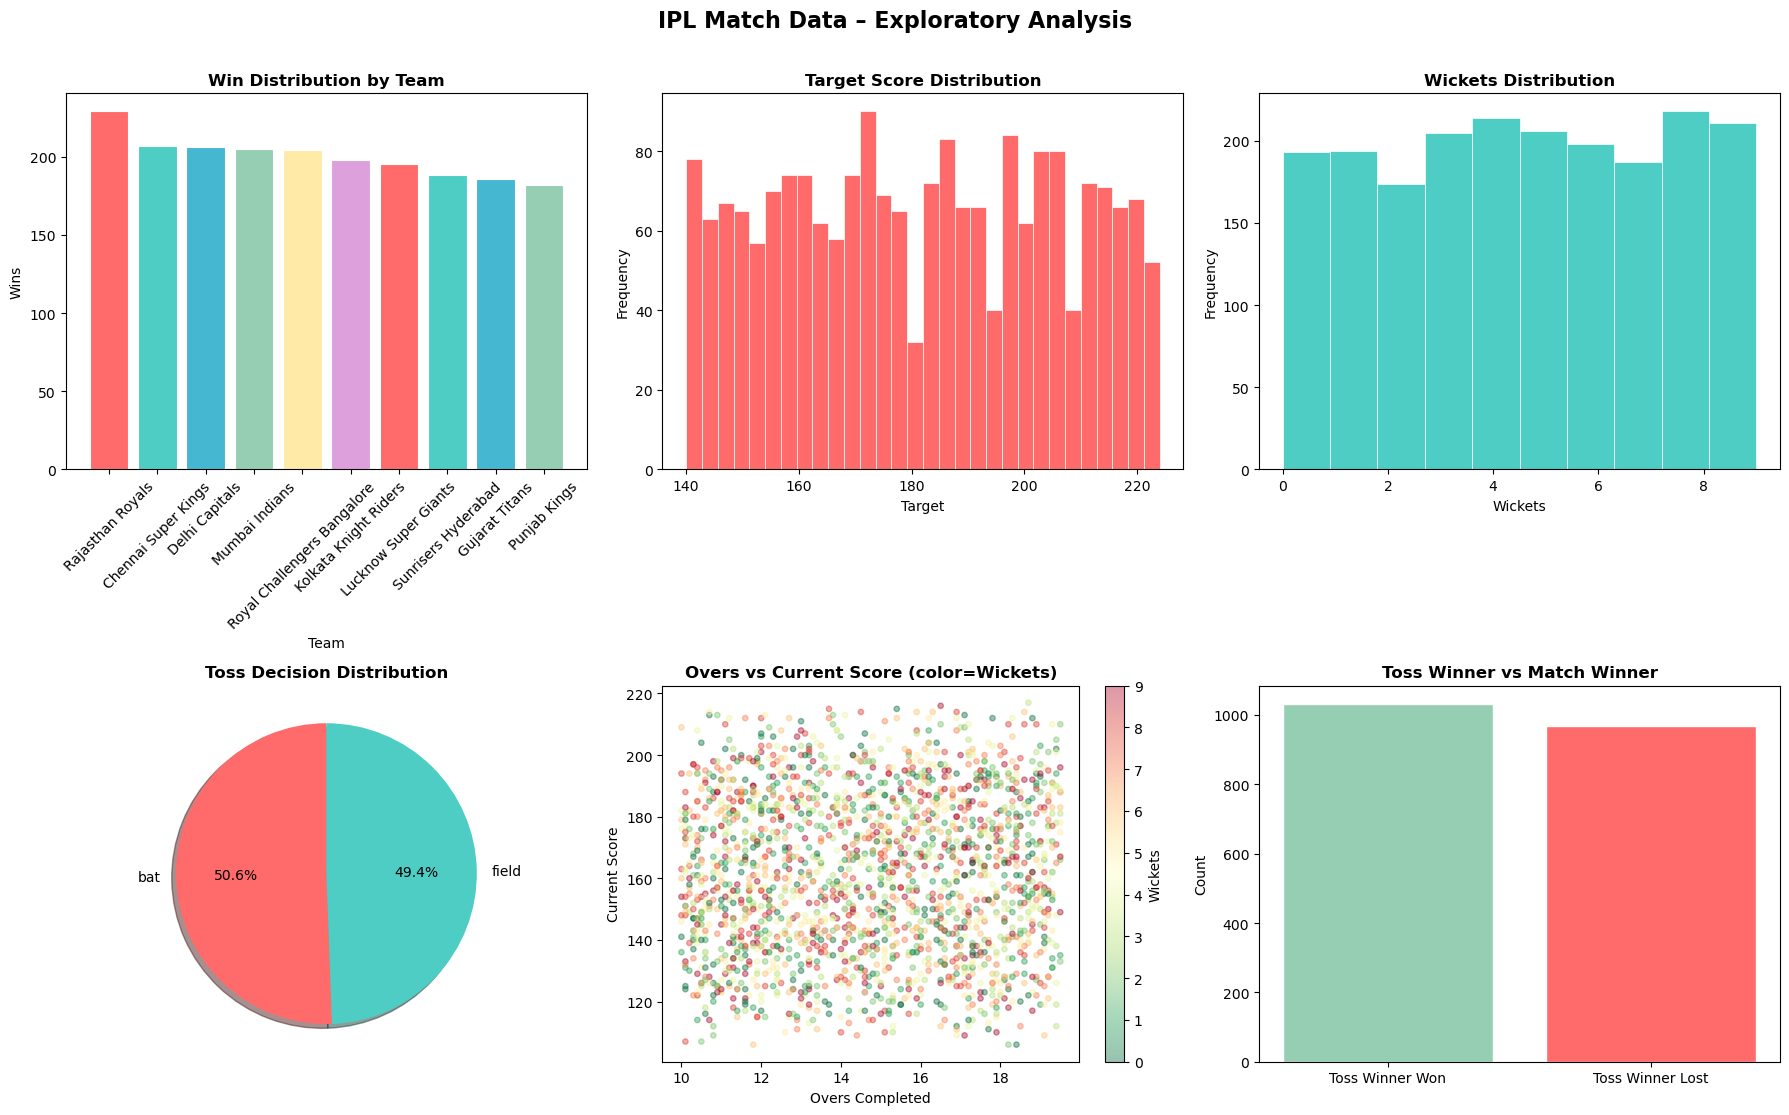

✅ EDA plots generated!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('IPL Match Data – Exploratory Analysis', fontsize=16, fontweight='bold', y=1.01)
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD']

# 1 – Win distribution
win_counts = df['result'].value_counts()
axes[0,0].bar(win_counts.index, win_counts.values,
              color=colors[:len(win_counts)], edgecolor='white', linewidth=0.8)
axes[0,0].set_title('Win Distribution by Team', fontweight='bold')
axes[0,0].set_xlabel('Team')
axes[0,0].set_ylabel('Wins')
axes[0,0].tick_params(axis='x', rotation=45)

# 2 – Target distribution
axes[0,1].hist(df['target'], bins=30, color='#FF6B6B', edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Target Score Distribution', fontweight='bold')
axes[0,1].set_xlabel('Target')
axes[0,1].set_ylabel('Frequency')

# 3 – Wickets distribution
axes[0,2].hist(df['wickets'], bins=10, color='#4ECDC4', edgecolor='white', linewidth=0.5)
axes[0,2].set_title('Wickets Distribution', fontweight='bold')
axes[0,2].set_xlabel('Wickets')
axes[0,2].set_ylabel('Frequency')

# 4 – Toss decision
toss_counts = df['toss_decision'].value_counts()
axes[1,0].pie(toss_counts.values, labels=toss_counts.index,
              autopct='%1.1f%%', colors=['#FF6B6B','#4ECDC4'],
              startangle=90, shadow=True)
axes[1,0].set_title('Toss Decision Distribution', fontweight='bold')

# 5 – Overs vs Score
scatter = axes[1,1].scatter(df['overs'], df['score'],
                             c=df['wickets'], cmap='RdYlGn_r',
                             alpha=0.4, s=15)
plt.colorbar(scatter, ax=axes[1,1], label='Wickets')
axes[1,1].set_title('Overs vs Current Score (color=Wickets)', fontweight='bold')
axes[1,1].set_xlabel('Overs Completed')
axes[1,1].set_ylabel('Current Score')

# 6 – Toss winner vs match winner
toss_win = (df['toss_winner'] == df['result']).value_counts()
axes[1,2].bar(['Toss Winner Won','Toss Winner Lost'],
               toss_win.values,
               color=['#96CEB4','#FF6B6B'], edgecolor='white')
axes[1,2].set_title('Toss Winner vs Match Winner', fontweight='bold')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA plots generated!')

## 🔧 Step 4: Data Preprocessing & Feature Engineering

In [6]:
df_processed = df.copy()

# ── Handle missing values ────────────────────────────────────────────────────
df_processed.fillna(df_processed.median(numeric_only=True), inplace=True)
df_processed.fillna(df_processed.mode().iloc[0],            inplace=True)

# ── Feature Engineering ──────────────────────────────────────────────────────
df_processed['runs_needed']      = df_processed['target'] - df_processed['score']
df_processed['balls_remaining']  = ((20 - df_processed['overs']) * 6).astype(int)
df_processed['wickets_remaining']= 10  - df_processed['wickets']
df_processed['current_run_rate'] = (df_processed['score'] /
                                    df_processed['overs'].replace(0, 0.1)).round(2)
df_processed['required_run_rate']= ((df_processed['runs_needed'] * 6) /
                                    df_processed['balls_remaining'].replace(0, 1)).round(2)
df_processed['run_rate_diff']    = (df_processed['required_run_rate'] -
                                    df_processed['current_run_rate']).round(2)
df_processed['toss_match_bat']   = (
    (df_processed['toss_winner'] == df_processed['batting_team']) &
    (df_processed['toss_decision'] == 'bat')
).astype(int)

# ── Label Encoding ───────────────────────────────────────────────────────────
le = {}
cat_cols = ['batting_team', 'bowling_team', 'city', 'toss_winner', 'toss_decision']
for col in cat_cols:
    le[col] = LabelEncoder()
    df_processed[col] = le[col].fit_transform(df_processed[col])

# Encode target (result)
le['result'] = LabelEncoder()
df_processed['result_encoded'] = le['result'].fit_transform(df_processed['result'])

print('✅ Feature Engineering Complete!')
print(f'\nNew features added:')
new_feats = ['runs_needed','balls_remaining','wickets_remaining',
             'current_run_rate','required_run_rate','run_rate_diff','toss_match_bat']
for f in new_feats:
    print(f'  • {f}')
df_processed.head(3)

✅ Feature Engineering Complete!

New features added:
  • runs_needed
  • balls_remaining
  • wickets_remaining
  • current_run_rate
  • required_run_rate
  • run_rate_diff
  • toss_match_bat


,batting_team,bowling_team,city,target,score,overs,wickets,toss_winner,toss_decision,result,runs_needed,balls_remaining,wickets_remaining,current_run_rate,required_run_rate,run_rate_diff,toss_match_bat,result_encoded
0,9,3,9,211,201,15.7,6,9,0,Sunrisers Hyderabad,10,25,4,12.80,2.40,-10.40,1,9
1,6,1,10,142,130,10.2,1,1,1,Punjab Kings,12,58,9,12.75,1.24,-11.51,0,6
2,7,0,6,215,196,15.8,8,7,0,Rajasthan Royals,19,25,2,12.41,4.56,-7.85,1,7


## 🤖 Step 5: Model Training – Random Forest Classifier

In [7]:
# ── Feature Selection ────────────────────────────────────────────────────────
feature_cols = [
    'batting_team', 'bowling_team', 'city',
    'target', 'score', 'overs', 'wickets',
    'toss_winner', 'toss_decision',
    'runs_needed', 'balls_remaining', 'wickets_remaining',
    'current_run_rate', 'required_run_rate', 'run_rate_diff',
    'toss_match_bat'
]

X = df_processed[feature_cols]
y = df_processed['result_encoded']

# ── Train-Test Split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 1600
Testing  samples : 400
Features         : 16


In [8]:
# ── Train Random Forest ──────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators    = 200,
    max_depth       = 15,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features    = 'sqrt',
    random_state    = 42,
    n_jobs          = -1
)

rf_model.fit(X_train, y_train)
print('✅ Random Forest Model trained successfully!')

✅ Random Forest Model trained successfully!


## 📈 Step 6: Model Evaluation

In [9]:
y_pred  = rf_model.predict(X_test)
y_prob  = rf_model.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('='*55)
print('        MODEL EVALUATION REPORT')
print('='*55)
print(f'✅ Accuracy Score : {accuracy:.4f} ({accuracy*100:.2f}%)')
print('\n📋 Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=le['result'].classes_
))

        MODEL EVALUATION REPORT
✅ Accuracy Score : 0.8150 (81.50%)

📋 Classification Report:
                             precision    recall  f1-score   support

        Chennai Super Kings       0.86      0.88      0.87        41
             Delhi Capitals       0.88      0.73      0.80        41
             Gujarat Titans       0.74      0.86      0.80        37
      Kolkata Knight Riders       0.68      0.75      0.71        40
       Lucknow Super Giants       0.79      0.77      0.78        39
             Mumbai Indians       0.87      0.80      0.84        41
               Punjab Kings       0.96      0.67      0.79        36
           Rajasthan Royals       0.82      0.89      0.85        46
Royal Challengers Bangalore       0.85      0.83      0.84        41
        Sunrisers Hyderabad       0.78      0.95      0.86        38

                   accuracy                           0.81       400
                  macro avg       0.82      0.81      0.81       400
        

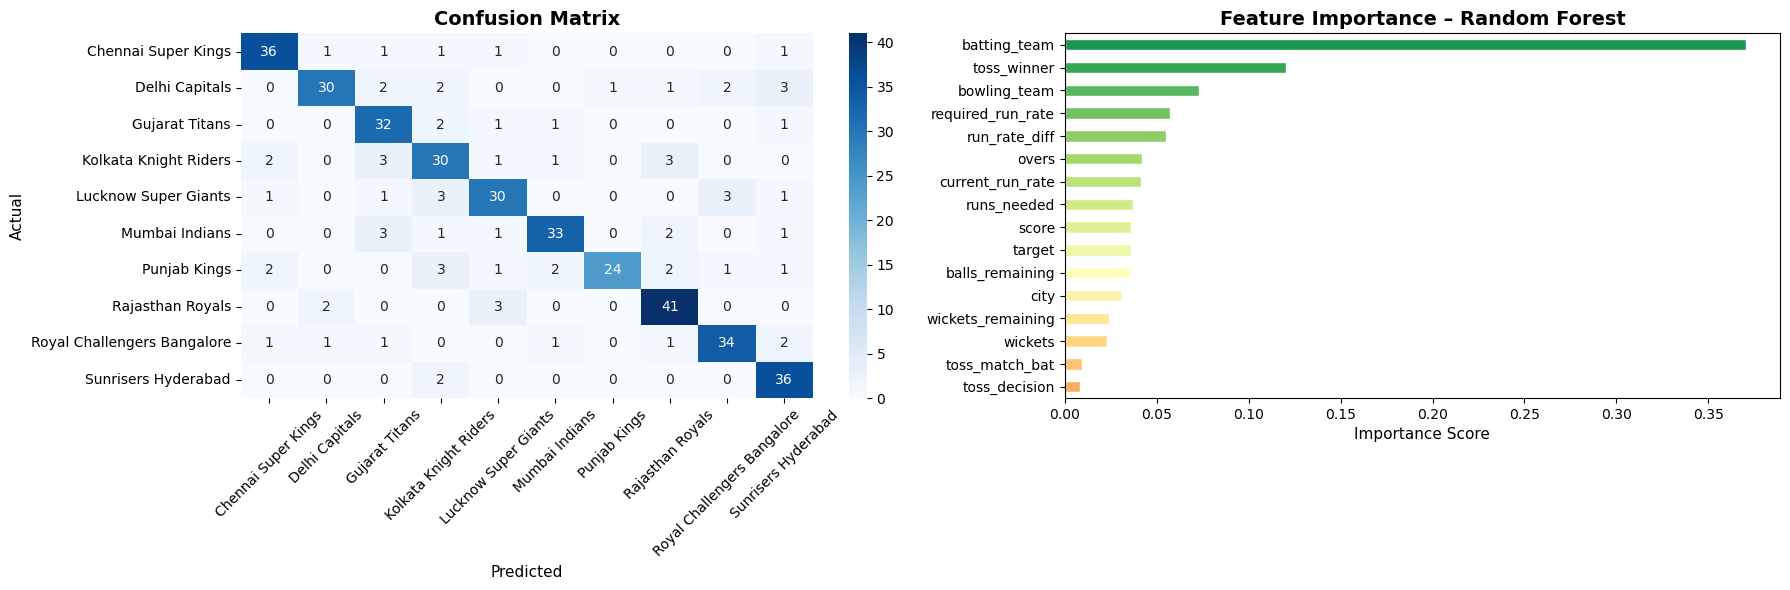

✅ Evaluation plots generated!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le['result'].classes_,
    yticklabels=le['result'].classes_,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual',    fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ── Feature Importance ───────────────────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=True)
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances_sorted)))
importances_sorted.plot(
    kind='barh', ax=axes[1],
    color=colors_fi, edgecolor='white'
)
axes[1].set_title('Feature Importance – Random Forest', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=11)

plt.tight_layout()
plt.savefig('model_eval.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Evaluation plots generated!')

## 💾 Step 7: Save Model with Pickle

In [12]:
MODEL_PATH = 'ipl_rf_model.pkl'

model_data = {
    'model'         : rf_model,
    'label_encoders': le,
    'feature_cols'  : feature_cols,
    'teams'         : teams,
    'cities'        : cities,
    'accuracy'      : accuracy
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_data, f)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'✅ Model saved → {MODEL_PATH}  ({size_kb:.1f} KB)')

✅ Model saved → ipl_rf_model.pkl  (13384.1 KB)


## 🔮 Step 8: Sample Prediction (Notebook Demo)

In [13]:
def predict_winner(input_dict, model_data):
    """
    Predict IPL match winner given match conditions.
    Returns (predicted_team, win_prob_pct, lose_prob_pct)
    """
    model    = model_data['model']
    encoders = model_data['label_encoders']
    feat_cols= model_data['feature_cols']

    enc = input_dict.copy()

    # Encode categoricals safely
    cat_cols_pred = ['batting_team', 'bowling_team', 'city', 'toss_winner', 'toss_decision']
    for col in cat_cols_pred:
        le_col = encoders[col]
        val    = enc[col]
        if val in le_col.classes_:
            enc[col] = le_col.transform([val])[0]
        else:
            enc[col] = 0  # unknown → default

    # Derived features
    enc['runs_needed']       = enc['target'] - enc['score']
    enc['balls_remaining']   = int((20 - enc['overs']) * 6)
    enc['wickets_remaining'] = 10 - enc['wickets']
    enc['current_run_rate']  = round(enc['score'] / max(enc['overs'], 0.1), 2)
    enc['required_run_rate'] = round((enc['runs_needed'] * 6) /
                                     max(enc['balls_remaining'], 1), 2)
    enc['run_rate_diff']     = round(enc['required_run_rate'] -
                                     enc['current_run_rate'], 2)

    # toss_match_bat: need original toss_winner and batting_team strings
    raw_batting = input_dict['batting_team']
    raw_toss_w  = input_dict['toss_winner']
    raw_toss_d  = input_dict['toss_decision']
    enc['toss_match_bat'] = int(
        raw_toss_w == raw_batting and raw_toss_d == 'bat'
    )

    X_input   = pd.DataFrame([enc])[feat_cols]
    pred_idx  = model.predict(X_input)[0]
    proba     = model.predict_proba(X_input)[0]
    pred_team = encoders['result'].inverse_transform([pred_idx])[0]
    win_prob  = round(proba[pred_idx] * 100, 2)
    lose_prob = round(100 - win_prob, 2)

    return pred_team, win_prob, lose_prob


# ── Load saved model ─────────────────────────────────────────────────────────
with open(MODEL_PATH, 'rb') as f:
    loaded_model_data = pickle.load(f)

# ── Demo prediction ──────────────────────────────────────────────────────────
sample_input = {
    'batting_team' : 'Mumbai Indians',
    'bowling_team' : 'Chennai Super Kings',
    'city'         : 'Mumbai',
    'target'       : 180,
    'score'        : 120,
    'overs'        : 14.0,
    'wickets'      : 4,
    'toss_winner'  : 'Mumbai Indians',
    'toss_decision': 'bat'
}

winner, win_p, lose_p = predict_winner(sample_input, loaded_model_data)

print('='*55)
print('         🏏 SAMPLE PREDICTION')
print('='*55)
print(f'  Batting Team   : {sample_input["batting_team"]}')
print(f'  Bowling Team   : {sample_input["bowling_team"]}')
print(f'  City           : {sample_input["city"]}')
print(f'  Target         : {sample_input["target"]}')
print(f'  Current Score  : {sample_input["score"]} / {sample_input["wickets"]}')
print(f'  Overs          : {sample_input["overs"]}')
print('-'*55)
print(f'  🏆 Predicted Winner : {winner}')
print(f'  📈 Win Probability   : {win_p}%')
print(f'  📉 Lose Probability  : {lose_p}%')
print('='*55)

         🏏 SAMPLE PREDICTION
  Batting Team   : Mumbai Indians
  Bowling Team   : Chennai Super Kings
  City           : Mumbai
  Target         : 180
  Current Score  : 120 / 4
  Overs          : 14.0
-------------------------------------------------------
  🏆 Predicted Winner : Chennai Super Kings
  📈 Win Probability   : 33.51%
  📉 Lose Probability  : 66.49%


## 🌐 Step 9: Flask Web Application
Run the cell below to start the web server, then open **http://localhost:5001** in your browser.

In [ ]:
from flask import Flask, render_template_string, request

# ── Reload model data ────────────────────────────────────────────────────────
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError('Model not found – run Steps 1-7 first.')

with open(MODEL_PATH, 'rb') as f:
    app_model_data = pickle.load(f)

APP_TEAMS  = app_model_data['teams']
APP_CITIES = app_model_data['cities']

# ────────────────────────────────────────────────────────────────────────────
#  HTML TEMPLATE
# ────────────────────────────────────────────────────────────────────────────
HTML_TEMPLATE = '''
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>🏏 IPL Match Predictor</title>
  <link href="https://fonts.googleapis.com/css2?family=Rajdhani:wght@400;600;700&family=Exo+2:wght@300;400;700&display=swap" rel="stylesheet">
  <style>
    /* ── Reset & Variables ──────────────────────────────────────────────── */
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }

    :root {
      --bg-dark   : #0a0e1a;
      --bg-card   : rgba(255,255,255,0.05);
      --border    : rgba(255,255,255,0.10);
      --gold      : #f0c040;
      --cyan      : #00d4ff;
      --pink      : #ff4fa3;
      --green     : #00e676;
      --red-loss  : #ff5252;
      --text-main : #e8eaf6;
      --text-dim  : #90a4ae;
      --radius    : 16px;
    }

    body {
      font-family     : 'Exo 2', sans-serif;
      background-color: var(--bg-dark);
      color           : var(--text-main);
      min-height      : 100vh;
      background-image:
        radial-gradient(ellipse at 10% 20%,  rgba(0,212,255,0.08) 0%, transparent 50%),
        radial-gradient(ellipse at 90% 80%,  rgba(255,79,163,0.08) 0%, transparent 50%),
        radial-gradient(ellipse at 50% 50%,  rgba(240,192,64,0.04) 0%, transparent 70%);
    }

    /* ── Navbar ─────────────────────────────────────────────────────────── */
    nav {
      display         : flex;
      align-items     : center;
      justify-content : space-between;
      padding         : 0 2.5rem;
      height          : 64px;
      background      : rgba(10,14,26,0.85);
      border-bottom   : 1px solid var(--border);
      backdrop-filter : blur(12px);
      position        : sticky;
      top             : 0;
      z-index         : 100;
    }
    .nav-brand {
      font-family  : 'Rajdhani', sans-serif;
      font-size    : 1.5rem;
      font-weight  : 700;
      background   : linear-gradient(90deg, var(--gold), var(--cyan));
      -webkit-background-clip: text;
      -webkit-text-fill-color: transparent;
      letter-spacing: 1px;
    }
    .nav-badge {
      background   : linear-gradient(135deg, var(--gold), var(--pink));
      color        : #0a0e1a;
      padding      : 4px 14px;
      border-radius: 20px;
      font-size    : 0.75rem;
      font-weight  : 700;
      letter-spacing: 0.5px;
    }

    /* ── Hero ───────────────────────────────────────────────────────────── */
    .hero {
      text-align    : center;
      padding       : 3.5rem 1rem 2rem;
    }
    .hero-title {
      font-family   : 'Rajdhani', sans-serif;
      font-size     : clamp(2rem, 5vw, 3.2rem);
      font-weight   : 700;
      line-height   : 1.1;
      background    : linear-gradient(135deg, var(--gold) 0%, var(--cyan) 50%, var(--pink) 100%);
      -webkit-background-clip: text;
      -webkit-text-fill-color: transparent;
      margin-bottom : 0.5rem;
    }
    .hero-sub {
      color      : var(--text-dim);
      font-size  : 0.95rem;
      letter-spacing: 0.5px;
    }
    .accuracy-pill {
      display     : inline-block;
      margin-top  : 1rem;
      background  : rgba(0,230,118,0.12);
      border      : 1px solid rgba(0,230,118,0.35);
      color       : var(--green);
      padding     : 5px 18px;
      border-radius: 20px;
      font-size   : 0.82rem;
      font-weight : 600;
      letter-spacing: 0.5px;
    }

    /* ── Layout ─────────────────────────────────────────────────────────── */
    .container {
      max-width : 1100px;
      margin    : 0 auto;
      padding   : 0 1.5rem 4rem;
    }

    /* ── Glass Card ─────────────────────────────────────────────────────── */
    .card {
      background     : var(--bg-card);
      border         : 1px solid var(--border);
      border-radius  : var(--radius);
      backdrop-filter: blur(12px);
      padding        : 2rem;
      transition     : transform .25s, box-shadow .25s;
    }
    .card:hover {
      transform : translateY(-3px);
      box-shadow: 0 12px 40px rgba(0,212,255,0.08);
    }

    /* ── Section Title ──────────────────────────────────────────────────── */
    .section-title {
      font-family  : 'Rajdhani', sans-serif;
      font-size    : 1.15rem;
      font-weight  : 700;
      letter-spacing: 1px;
      color        : var(--gold);
      margin-bottom: 1.5rem;
      display      : flex;
      align-items  : center;
      gap          : 0.5rem;
    }
    .section-title::after {
      content   : '';
      flex      : 1;
      height    : 1px;
      background: linear-gradient(90deg, var(--gold), transparent);
      margin-left: 8px;
    }

    /* ── Grid ───────────────────────────────────────────────────────────── */
    .grid-2 { display: grid; grid-template-columns: 1fr 1fr; gap: 1rem; }
    .grid-3 { display: grid; grid-template-columns: repeat(3,1fr); gap: 1rem; }
    @media (max-width: 768px) {
      .grid-2, .grid-3 { grid-template-columns: 1fr; }
    }

    /* ── Form Fields ────────────────────────────────────────────────────── */
    .form-group {
      display       : flex;
      flex-direction: column;
      gap           : 6px;
    }
    label {
      font-size    : 0.75rem;
      font-weight  : 700;
      text-transform: uppercase;
      letter-spacing: 0.8px;
      color        : var(--text-dim);
    }
    select, input[type=number] {
      background   : rgba(255,255,255,0.06);
      border       : 1px solid var(--border);
      border-radius: 10px;
      color        : var(--text-main);
      padding      : 11px 14px;
      font-family  : inherit;
      font-size    : 0.9rem;
      outline      : none;
      transition   : border-color .2s, box-shadow .2s;
      width        : 100%;
    }
    select:focus, input[type=number]:focus {
      border-color : var(--cyan);
      box-shadow   : 0 0 0 3px rgba(0,212,255,0.12);
    }
    select option { background: #141828; }

    /* ── Predict Button ─────────────────────────────────────────────────── */
    .btn-predict {
      width         : 100%;
      margin-top    : 1.75rem;
      padding       : 15px;
      border        : none;
      border-radius : 12px;
      background    : linear-gradient(135deg, #f0c040, #ff9f00);
      color         : #0a0e1a;
      font-family   : 'Rajdhani', sans-serif;
      font-size     : 1.1rem;
      font-weight   : 700;
      letter-spacing: 1.5px;
      cursor        : pointer;
      transition    : transform .2s, box-shadow .2s, filter .2s;
      position      : relative;
      overflow      : hidden;
    }
    .btn-predict::after {
      content   : '';
      position  : absolute;
      inset     : 0;
      background: linear-gradient(135deg, rgba(255,255,255,0.2), transparent);
      opacity   : 0;
      transition: opacity .2s;
    }
    .btn-predict:hover {
      transform : translateY(-2px);
      box-shadow: 0 8px 28px rgba(240,192,64,0.45);
      filter    : brightness(1.08);
    }
    .btn-predict:hover::after { opacity: 1; }
    .btn-predict:active { transform: translateY(0); }

    /* ── Result Section ─────────────────────────────────────────────────── */
    .result-section { margin-top: 2rem; }

    .winner-banner {
      text-align   : center;
      padding      : 2rem;
      border-radius: var(--radius);
      background   : linear-gradient(135deg,
                       rgba(240,192,64,0.12),
                       rgba(0,212,255,0.08));
      border       : 1px solid rgba(240,192,64,0.3);
      margin-bottom: 1.5rem;
      animation    : fadeUp .5s ease both;
    }
    @keyframes fadeUp {
      from { opacity:0; transform: translateY(20px); }
      to   { opacity:1; transform: translateY(0);    }
    }
    .winner-emoji { font-size: 3rem; }
    .winner-label {
      color      : var(--text-dim);
      font-size  : 0.8rem;
      text-transform: uppercase;
      letter-spacing: 1.5px;
      margin     : 0.5rem 0 0.25rem;
    }
    .winner-name {
      font-family : 'Rajdhani', sans-serif;
      font-size   : 2rem;
      font-weight : 700;
      background  : linear-gradient(90deg, var(--gold), var(--cyan));
      -webkit-background-clip: text;
      -webkit-text-fill-color: transparent;
    }

    /* ── Probability Bars ───────────────────────────────────────────────── */
    .prob-row {
      display        : flex;
      align-items    : center;
      gap            : 12px;
      margin-bottom  : 0.85rem;
    }
    .prob-label { width: 36px; font-size: 0.75rem; color: var(--text-dim); text-align: right; }
    .prob-bar-wrap {
      flex          : 1;
      height        : 14px;
      border-radius : 7px;
      background    : rgba(255,255,255,0.07);
      overflow      : hidden;
    }
    .prob-bar {
      height        : 100%;
      border-radius : 7px;
      transition    : width 1s cubic-bezier(.4,0,.2,1);
    }
    .prob-bar.win  { background: linear-gradient(90deg, var(--green), var(--cyan)); }
    .prob-bar.lose { background: linear-gradient(90deg, var(--red-loss), var(--pink)); }
    .prob-value { width: 48px; font-size: 0.85rem; font-weight: 700; }
    .prob-value.win  { color: var(--green); }
    .prob-value.lose { color: var(--red-loss); }

    /* ── Summary Grid ───────────────────────────────────────────────────── */
    .summary-grid {
      display              : grid;
      grid-template-columns: repeat(auto-fill, minmax(150px, 1fr));
      gap                  : 1rem;
      margin-top           : 0.5rem;
    }
    .summary-item {
      background   : rgba(255,255,255,0.04);
      border       : 1px solid var(--border);
      border-radius: 12px;
      padding      : 1rem 1.1rem;
      text-align   : center;
    }
    .summary-val {
      font-family  : 'Rajdhani', sans-serif;
      font-size    : 1.4rem;
      font-weight  : 700;
      color        : var(--cyan);
    }
    .summary-key {
      font-size    : 0.72rem;
      color        : var(--text-dim);
      text-transform: uppercase;
      letter-spacing: 0.6px;
      margin-top   : 4px;
    }

    /* ── Error Banner ───────────────────────────────────────────────────── */
    .error-banner {
      background   : rgba(255,82,82,0.12);
      border       : 1px solid rgba(255,82,82,0.35);
      border-radius: 12px;
      padding      : 1rem 1.5rem;
      color        : #ff8a80;
      margin-top   : 1.5rem;
      animation    : fadeUp .4s ease both;
    }

    /* ── Footer ─────────────────────────────────────────────────────────── */
    footer {
      text-align   : center;
      padding      : 1.5rem 0 2.5rem;
      color        : var(--text-dim);
      font-size    : 0.78rem;
      border-top   : 1px solid var(--border);
      margin-top   : 3rem;
    }
    footer span { color: var(--gold); }

    /* ── Divider ─────────────────────────────────────────────────────────── */
    .divider { height: 1px; background: var(--border); margin: 1.75rem 0; }
  </style>
</head>
<body>

<!-- ── Navbar ─────────────────────────────────────────────────────────────── -->
<nav>
  <div class="nav-brand">🏏 IPL PREDICTOR</div>
  <div class="nav-badge">Random Forest ML</div>
</nav>

<!-- ── Hero ───────────────────────────────────────────────────────────────── -->
<div class="hero">
  <h1 class="hero-title">IPL Match Winner Prediction</h1>
  <p class="hero-sub">AI-powered predictions based on live match conditions</p>
  {% if accuracy %}
  <div class="accuracy-pill">✅ Model Accuracy: {{ accuracy }}%</div>
  {% endif %}
</div>

<div class="container">

  <!-- ── FORM CARD ──────────────────────────────────────────────────────── -->
  <div class="card">
    <div class="section-title">🏟️ Match Conditions</div>
    <form method="POST" action="/predict">

      <!-- Teams & City -->
      <div class="grid-3">
        <div class="form-group">
          <label>🏏 Batting Team</label>
          <select name="batting_team" required>
            {% for t in teams %}
            <option value="{{ t }}" {% if form.batting_team == t %}selected{% endif %}>{{ t }}</option>
            {% endfor %}
          </select>
        </div>
        <div class="form-group">
          <label>🎯 Bowling Team</label>
          <select name="bowling_team" required>
            {% for t in teams %}
            <option value="{{ t }}" {% if form.bowling_team == t %}selected{% endif %}>{{ t }}</option>
            {% endfor %}
          </select>
        </div>
        <div class="form-group">
          <label>📍 City / Venue</label>
          <select name="city" required>
            {% for c in cities %}
            <option value="{{ c }}" {% if form.city == c %}selected{% endif %}>{{ c }}</option>
            {% endfor %}
          </select>
        </div>
      </div>

      <div class="divider"></div>

      <!-- Scores -->
      <div class="grid-3">
        <div class="form-group">
          <label>🎯 Target Score</label>
          <input type="number" name="target" min="100" max="280"
                 placeholder="e.g. 185" value="{{ form.target or '' }}" required />
        </div>
        <div class="form-group">
          <label>🏃 Current Score</label>
          <input type="number" name="score" min="0" max="280"
                 placeholder="e.g. 110" value="{{ form.score or '' }}" required />
        </div>
        <div class="form-group">
          <label>⏱️ Overs Completed</label>
          <input type="number" name="overs" min="0.1" max="19.5" step="0.1"
                 placeholder="e.g. 13.4" value="{{ form.overs or '' }}" required />
        </div>
      </div>

      <div class="divider"></div>

      <!-- Wickets & Toss -->
      <div class="grid-3">
        <div class="form-group">
          <label>🚨 Wickets Out</label>
          <input type="number" name="wickets" min="0" max="9"
                 placeholder="e.g. 4" value="{{ form.wickets or '' }}" required />
        </div>
        <div class="form-group">
          <label>🪙 Toss Winner</label>
          <select name="toss_winner" required>
            {% for t in teams %}
            <option value="{{ t }}" {% if form.toss_winner == t %}selected{% endif %}>{{ t }}</option>
            {% endfor %}
          </select>
        </div>
        <div class="form-group">
          <label>⚡ Toss Decision</label>
          <select name="toss_decision" required>
            <option value="bat"   {% if form.toss_decision == 'bat'   %}selected{% endif %}>Bat</option>
            <option value="field" {% if form.toss_decision == 'field' %}selected{% endif %}>Field</option>
          </select>
        </div>
      </div>

      <button type="submit" class="btn-predict">⚡ PREDICT WINNER</button>
    </form>
  </div>

  <!-- ── ERROR ────────────────────────────────────────────────────────────── -->
  {% if error %}
  <div class="error-banner">⚠️ {{ error }}</div>
  {% endif %}

  <!-- ── RESULT ───────────────────────────────────────────────────────────── -->
  {% if result %}
  <div class="result-section">

    <!-- Winner Banner -->
    <div class="winner-banner">
      <div class="winner-emoji">🏆</div>
      <p class="winner-label">Predicted Winner</p>
      <div class="winner-name">{{ result.winner }}</div>
    </div>

    <div class="grid-2">

      <!-- Probability Card -->
      <div class="card">
        <div class="section-title">📊 Win Probability</div>

        <div class="prob-row">
          <span class="prob-label">WIN</span>
          <div class="prob-bar-wrap">
            <div class="prob-bar win" style="width: {{ result.win_prob }}%"></div>
          </div>
          <span class="prob-value win">{{ result.win_prob }}%</span>
        </div>

        <div class="prob-row">
          <span class="prob-label">LOSE</span>
          <div class="prob-bar-wrap">
            <div class="prob-bar lose" style="width: {{ result.lose_prob }}%"></div>
          </div>
          <span class="prob-value lose">{{ result.lose_prob }}%</span>
        </div>
      </div>

      <!-- Match Summary Card -->
      <div class="card">
        <div class="section-title">📋 Match Summary</div>
        <div class="summary-grid">
          <div class="summary-item">
            <div class="summary-val">{{ result.runs_needed }}</div>
            <div class="summary-key">Runs Needed</div>
          </div>
          <div class="summary-item">
            <div class="summary-val">{{ result.balls_left }}</div>
            <div class="summary-key">Balls Left</div>
          </div>
          <div class="summary-item">
            <div class="summary-val">{{ result.wkts_left }}</div>
            <div class="summary-key">Wkts Remaining</div>
          </div>
          <div class="summary-item">
            <div class="summary-val">{{ result.crr }}</div>
            <div class="summary-key">Curr. Run Rate</div>
          </div>
          <div class="summary-item">
            <div class="summary-val">{{ result.rrr }}</div>
            <div class="summary-key">Req. Run Rate</div>
          </div>
        </div>
      </div>
    </div>
  </div>
  {% endif %}

</div>

<footer>
  Built with <span>♥</span> · Random Forest Classifier · scikit-learn · Flask
</footer>

</body>
</html>
'''

# ── Flask App ────────────────────────────────────────────────────────────────
app = Flask(__name__)

@app.route('/', methods=['GET'])
def index():
    acc = round(app_model_data['accuracy'] * 100, 2)
    return render_template_string(
        HTML_TEMPLATE,
        teams    = APP_TEAMS,
        cities   = APP_CITIES,
        result   = None,
        error    = None,
        form     = {},
        accuracy = acc
    )

@app.route('/predict', methods=['POST'])
def predict():
    acc  = round(app_model_data['accuracy'] * 100, 2)
    form = request.form

    try:
        inp = {
            'batting_team' : form['batting_team'],
            'bowling_team' : form['bowling_team'],
            'city'         : form['city'],
            'target'       : float(form['target']),
            'score'        : float(form['score']),
            'overs'        : float(form['overs']),
            'wickets'      : int(form['wickets']),
            'toss_winner'  : form['toss_winner'],
            'toss_decision': form['toss_decision']
        }

        if inp['batting_team'] == inp['bowling_team']:
            raise ValueError('Batting and bowling teams must be different.')
        if inp['score'] >= inp['target']:
            raise ValueError('Current score must be less than target.')
        if inp['overs'] <= 0 or inp['overs'] >= 20:
            raise ValueError('Overs must be between 0.1 and 19.5.')

        winner, win_p, lose_p = predict_winner(inp, app_model_data)

        runs_needed = int(inp['target'] - inp['score'])
        balls_left  = max(0, int((20 - inp['overs']) * 6))
        wkts_left   = 10 - inp['wickets']
        crr         = round(inp['score'] / max(inp['overs'], 0.1), 2)
        rrr         = round((runs_needed * 6) / max(balls_left, 1), 2)

        result = {
            'winner'     : winner,
            'win_prob'   : win_p,
            'lose_prob'  : lose_p,
            'runs_needed': runs_needed,
            'balls_left' : balls_left,
            'wkts_left'  : wkts_left,
            'crr'        : crr,
            'rrr'        : rrr,
        }

        return render_template_string(
            HTML_TEMPLATE,
            teams    = APP_TEAMS,
            cities   = APP_CITIES,
            result   = result,
            error    = None,
            form     = form,
            accuracy = acc
        )

    except Exception as e:
        return render_template_string(
            HTML_TEMPLATE,
            teams    = APP_TEAMS,
            cities   = APP_CITIES,
            result   = None,
            error    = str(e),
            form     = form,
            accuracy = acc
        )


print('🚀 Starting Flask server...')
print('📌 Open http://localhost:5001 in your browser')
print('   (Press Ctrl+C to stop the server)')
app.run(debug=False, port=5001, use_reloader=False)

🚀 Starting Flask server...
📌 Open http://localhost:5001 in your browser
   (Press Ctrl+C to stop the server)
 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5001/ (Press CTRL+C to quit)
127.0.0.1 - - [19/May/2026 11:59:20] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [19/May/2026 11:59:20] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [19/May/2026 12:00:37] "POST /predict HTTP/1.1" 200 -


---
## ✅ Project Complete!

| Step | Description | Status |
|------|-------------|--------|
| 1 | Library Imports | ✅ |
| 2 | Dataset Generation | ✅ |
| 3 | Exploratory Data Analysis | ✅ |
| 4 | Feature Engineering & Preprocessing | ✅ |
| 5 | Random Forest Model Training | ✅ |
| 6 | Model Evaluation (Accuracy, CM, Report) | ✅ |
| 7 | Model Saved with Pickle | ✅ |
| 8 | Sample Prediction Demo | ✅ |
| 9 | Flask Web App (port 5001) | ✅ |

**To run the web app:** Execute cells 1–8 first, then run cell 9. Open `http://localhost:5001` in your browser.